# Redes neuronales para la resolución de problemas de regresión y clasificación

Vamos a emplear la base de datos de precios de casas de Boston (https://www.kaggle.com/c/boston-housing) en el que, dado una base
de datos de 506 casas con 13 características asociadas a cada una de ellas, se pretende predecir el precio de la misma.

Para comprender la diferencia entre la resolución de problemas de regresión y clasificación vamos a abordar el problema de dos formas diferentes:



*   Regresión: Predicción del precio de la casa
*   Clasificación: Predicción si el precio de la casa va a ser ALTO, MEDIO o BAJO.

Descripción

Este conjunto de datos contiene información recopilada por el Servicio de Censos de los EE.UU. sobre las viviendas en el área de Boston
Mass. Se obtuvo del archivo StatLib (http://lib.stat.cmu.edu/datasets/boston), y se ha utilizado extensamente en toda la literatura para
comparar diferentes algoritmos de Machine Learning.

Los datos fueron publicados originalmente por Harrison, D. y Rubinfeld, D.L. Precios hedónicos y la demanda de aire limpio', J. Environ.
Economics & Management, vol.5, 81-102, 1978.


Características del conjunto de datos
El conjunto de datos es pequeño, con sólo 506 casos. Contiene 14 características que se describen a continuación:

CRIM: per capita crime rate by town

ZN: proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: proportion of non-retail business acres per town.

CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)

NOX: nitric oxides concentration (parts per 10 million)

RM: average number of rooms per dwelling

AGE: proportion of owner-occupied units built prior to 1940

DIS: weighted distances to five Boston employment centres

RAD: index of accessibility to radial highways

TAX: full-value property-tax rate per 10,000 dollars

PTRATIO: pupil-teacher ratio by town

B: 1000(Bk — 0.63)² where Bk is the proportion of blacks by town
LSTAT: % lower status of the population

MEDV: Median value of owner-occupied homes in 1000 dollars

# Regresión -> Número



## Paso 1: Cargado y preparación de los datos

In [ ]:
# Dependencias que vamos a emplear durante la sesión
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from itertools import cycle
import numpy as np
import pandas as pd

In [ ]:
(X_train_val, y_train_val), (X_test, y_test) = keras.datasets.boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print('Entrada entrenamiento/validación: ', X_train_val.shape)
print('Salida entrenamiento/validación: ', y_train_val.shape)
print('Entrada test: ', X_test.shape)
print('Salida test: ', y_test.shape)

Entrada entrenamiento/validación:  (404, 13)
Salida entrenamiento/validación:  (404,)
Entrada test:  (102, 13)
Salida test:  (102,)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2)

In [ ]:
print('Entrada entrenamiento: ', X_train.shape)
print('Salida entrenamiento: ', y_train.shape)
print('Entrada validación: ', X_val.shape)
print('Salida validación: ', y_val.shape)

Entrada entrenamiento:  (323, 13)
Salida entrenamiento:  (323,)
Entrada validación:  (81, 13)
Salida validación:  (81,)


Text(0.5, 1.0, 'Test. Min: 5.6, Max: 50.0, Media: 23.07843137254902')

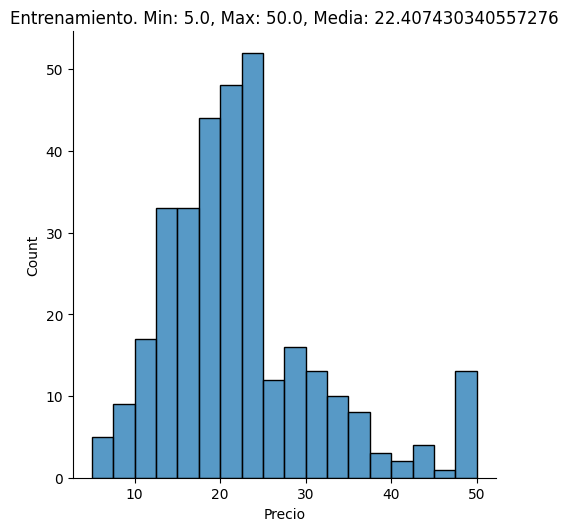

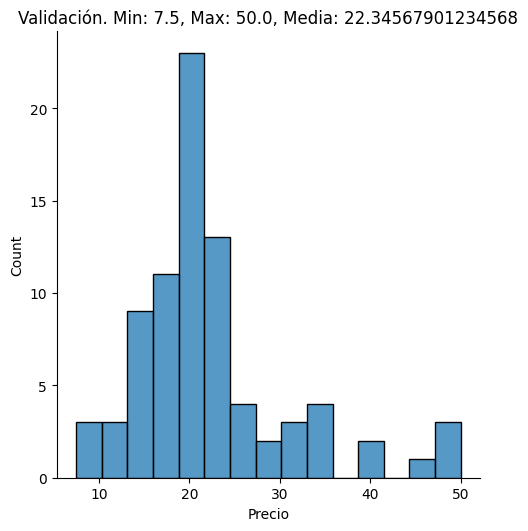

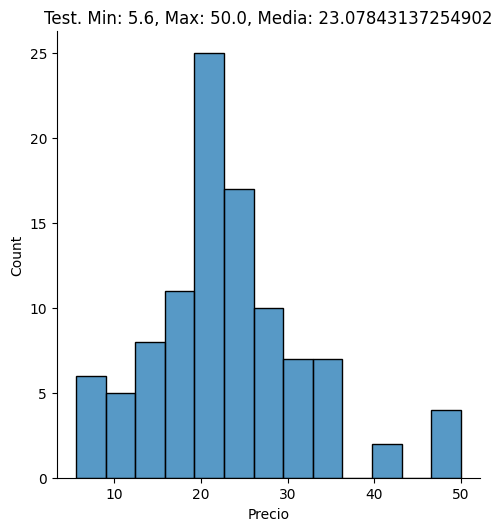

In [ ]:
# Visualizamos la salida en cada uno de los grupos para hacernos una idea de las distribuciones
sns.displot(y_train)
plt.xlabel('Precio')
plt.title(f'Entrenamiento. Min: {y_train.min()}, Max: {y_train.max()}, Media: {y_train.mean()}')
sns.displot(y_val)
plt.xlabel('Precio')
plt.title(f'Validación. Min: {y_val.min()}, Max: {y_val.max()}, Media: {y_val.mean()}')
sns.displot(y_test)
plt.xlabel('Precio')
plt.title(f'Test. Min: {y_test.min()}, Max: {y_test.max()}, Media: {y_test.mean()}')

En los tres subconjuntos las distribuciones de la variables salida (precio) son similares. Todas tienen valores similares mínimos, máximos y
medios.
A continuación vamos a analizar las características de entrada. En primer lugar vamos a analizar los rangos en los que éstas se
encuentran. Estas se comportan mejor cuando tratamos con variables con valores en la misma escala.

In [ ]:
# Vamos el rango de las variables
print('Valores mínimos variables: ', X_train.min(axis=0))
print('Valores máximos variables: ', X_train.max(axis=0))

Valores mínimos variables:  [6.3200e-03 0.0000e+00 4.6000e-01 0.0000e+00 3.8500e-01 3.5610e+00
 2.9000e+00 1.1296e+00 1.0000e+00 1.8800e+02 1.2600e+01 3.2000e-01
 1.7300e+00]
Valores máximos variables:  [ 88.9762 100.      27.74     1.       0.871    8.725  100.      10.7103
  24.     711.      22.     396.9     36.98  ]


Vemos que están en escalas diferentes, para evitar el mayor efecto de unas variables frente a otras vamos a normalizar todas las variables
siguiendo una estrategía z-score

In [ ]:
# La normalización se realiza empleando el valor medio y desviación estándar del conjunto de datos de entrenamiento.
# Estos mismos valores son los que se emplearán para normalizar los conjuntos de datos de validación y test.
# Normalización de los datos
train_mean_x = X_train.mean()
train_std_x = X_train.std()


# Save the mean and std values
np.save('./mean.npy', train_mean_x)
np.save('./std.npy', train_std_x)

X_train_norm = (X_train - train_mean_x) / train_std_x
X_val_norm = (X_val - train_mean_x) / train_std_x
X_test_norm = (X_test - train_mean_x) / train_std_x

# Vamos el rango de las variables normalizadas
print('Valores mínimos variables normalizadas: ', X_train_norm.min(axis=0))
print('Valores máximos variables normalizadas: ', X_train_norm.max(axis=0))

Valores mínimos variables normalizadas:  [-0.48220479 -0.48224822 -0.47908709 -0.48224822 -0.47960249 -0.45777694
 -0.46231935 -0.47448558 -0.4753762   0.80969228 -0.39566072 -0.48004917
 -0.47035962]
Valores máximos variables normalizadas:  [ 0.12919836  0.20495417 -0.29161828 -0.4753762  -0.47626269 -0.42228981
  0.20495417 -0.40864678 -0.31731965  4.4037608  -0.33106369  2.24525808
 -0.22812078]


Ya podemos ver como, tras realizar la normalización, las variables se encuentran en escalas similares.

In [ ]:
features = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

df=pd.DataFrame(X_train, columns=features)
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.28392,0.0,7.38,0.0,0.493,5.708,74.3,4.7211,5.0,287.0,19.6,391.13,11.74
1,0.05083,0.0,5.19,0.0,0.515,6.316,38.1,6.4584,5.0,224.0,20.2,389.71,5.68
2,0.06860,0.0,2.89,0.0,0.445,7.416,62.5,3.4952,2.0,276.0,18.0,396.90,6.19
3,0.11425,0.0,13.89,1.0,0.550,6.373,92.4,3.3633,5.0,276.0,16.4,393.74,10.50
4,0.08244,30.0,4.93,0.0,0.428,6.481,18.5,6.1899,6.0,300.0,16.6,379.41,6.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...
318,0.07978,40.0,6.41,0.0,0.447,6.482,32.1,4.1403,4.0,254.0,17.6,396.90,7.19
319,0.28960,0.0,9.69,0.0,0.585,5.390,72.9,2.7986,6.0,391.0,19.2,396.90,21.14
320,0.54011,20.0,3.97,0.0,0.647,7.203,81.8,2.1121,5.0,264.0,13.0,392.80,9.59
321,0.04590,52.5,5.32,0.0,0.405,6.315,45.6,7.3172,6.0,293.0,16.6,396.90,7.60


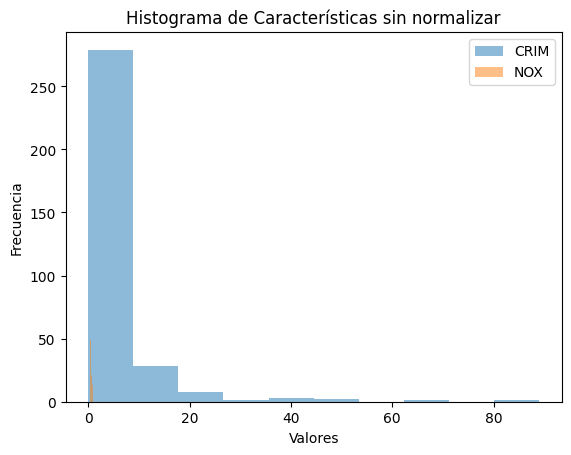

In [ ]:
# Histograma para la primera columna
plt.hist(X_train[:, 0], alpha=0.5, label='CRIM')
# Histograma para la quinta columna
plt.hist(X_train[:, 4], alpha=0.5, label='NOX')
# Agregar etiquetas al eje x e y
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
# Agregar una leyenda
plt.legend()
# Agregar un título al gráfico
plt.title('Histograma de Características sin normalizar')
# Mostrar el gráfico
plt.show()

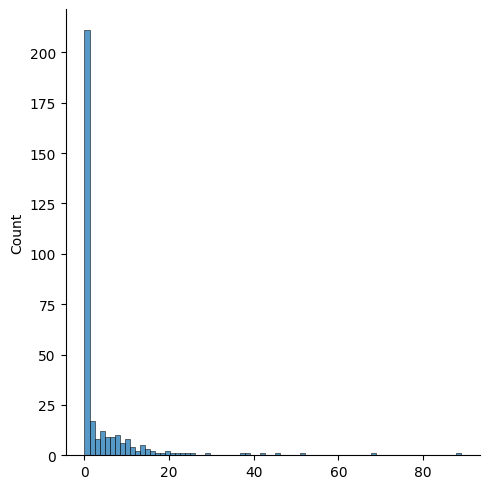

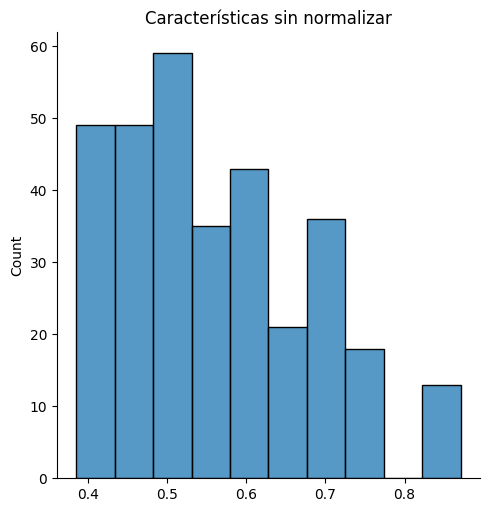

In [ ]:
sns.displot(X_train[:, 0])
sns.displot(X_train[:, 4])
plt.title('Características sin normalizar')
plt.show()

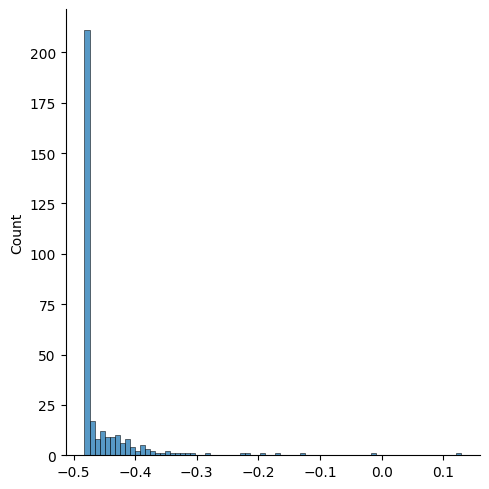

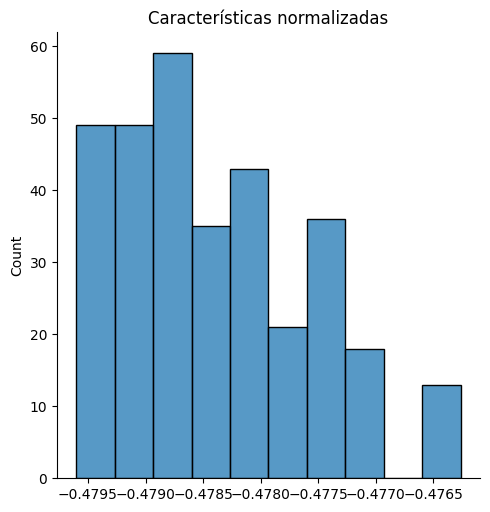

In [ ]:
sns.displot(X_train_norm[:, 0])
sns.displot(X_train_norm[:, 4])
plt.title('Características normalizadas')
plt.show()

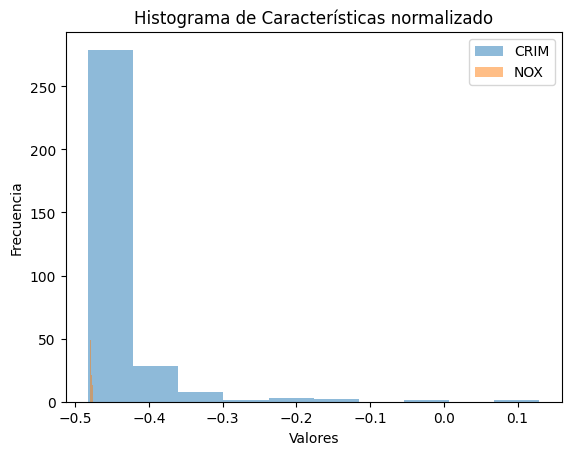

In [ ]:
# Histograma para la primera columna
plt.hist(X_train_norm[:, 0], alpha=0.5, label='CRIM')
# Histograma para la quinta columna
plt.hist(X_train_norm[:, 4], alpha=0.5, label='NOX')
# Agregar etiquetas al eje x e y
plt.xlabel('Valores')
plt.ylabel('Frecuencia')
# Agregar una leyenda
plt.legend()
# Agregar un título al gráfico
plt.title('Histograma de Características normalizado')
# Mostrar el gráfico
plt.show()

NOTA: En el paso de preparación de los datos, se deberán de llevar a cabo todas las tareas que ya habréis visto en la parte de Machine
Learning de Análisis Exploratorio de los Datos (EDA), como puede ser: tratamiento de datos faltante, valores atípicos, correlaciones, etc.

## Paso 2: Construcción del modelo

Para construir el modelo primero debemos definir la arquitectura deseada, es decir, el conjunto de capas que forma la red neuronal. Una
vez definida la arquitectura se debe especificar la función de coste a emplear, el optimizador para la actualización de los pesos y las
métricas para monitorizar el proceso de entrenamiento.

Para esto emplearemos el método "compile()" que hace uso de los parámetros:

*   optimizer: Optimizador que define cómo se actualizan los pesos.
*   loss: Función de coste a optimizar durante el entrenamiento.
*   metrics: Métricas que se computan al final de cada iteración para monitorizar el proeso de entrenamiento. Se computan tanto sobre
el conjunto de entrenamiento como, en su caso, el de validación.


En primer lugar vamos a construir una arquitectura sencilla formada por la capa de entrada, una capa oculta con 20 nueronas y la capa
de salida. Como función de coste emplearemos el error cuadrático medio.

In [ ]:
# Creamos un método que define la arquitectura del modelo
def create_model_regression(n_features):
  model = keras.Sequential()
  model.add(Dense(20, activation='relu', input_shape=(n_features,)))
  model.add(Dense(1)) #Por defecto se emplea función de activación lineal (None)
  return model

# Definimos la arquitectura del modelo
model_regression = create_model_regression(X_train.shape[1])
# Compilamos
model_regression.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])
model_regression.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

## Paso 3: Entrenamiento del modelo

Una vez definido el modelo hay que entrenarlo, para ello se hade uso del método "fit()" y definiremos el conjunto de datos de
entrenamiento, validación, el número de épocas y el tamaño de batch.

In [ ]:
history_reg = model_regression.fit(X_train_norm, y_train, epochs=200, batch_size=64, validation_data=(X_val_norm, y_val))

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 287ms/step - loss: 614.8445 - mae: 22.9864 - mse: 614.8445 - val_loss: 589.6602 - val_mae: 22.6395 - val_mse: 589.6602
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 611.5699 - mae: 22.9371 - mse: 611.5699 - val_loss: 578.9661 - val_mae: 22.4012 - val_mse: 578.9661
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 577.4785 - mae: 22.1569 - mse: 577.4785 - val_loss: 568.1499 - val_mae: 22.1584 - val_mse: 568.1499
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 592.9668 - mae: 22.4419 - mse: 592.9668 - val_loss: 557.3036 - val_mae: 21.9121 - val_mse: 557.3036
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 590.5681 - mae: 22.2448 - mse: 590.5681 - val_loss: 546.6861 - val_mae: 21.6680 - val_mse: 546.6861
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 526.3562 - mae: 21.0707 - mse: 526.3562 - val_loss: 536.0945 - val_mae: 21.4219 - val_mse: 536.0945
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step -

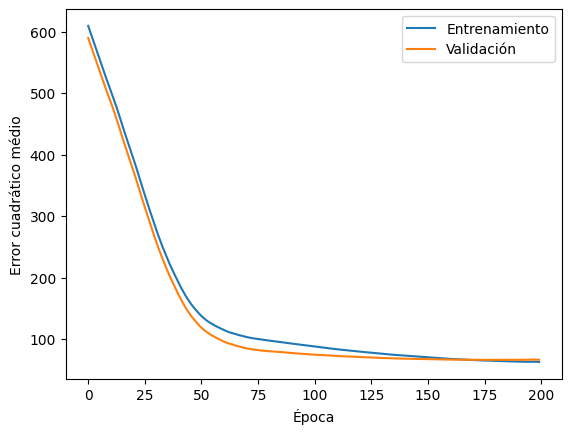

In [ ]:
# Visualizamos el error cuadrático medio obtenido durante el proceso de entrenamiento tanto en entrenamiento como en validación
def plot_history():
  plt.plot(history_reg.history['mse'], label="Entrenamiento")
  plt.plot(history_reg.history['val_mse'], label="Validación")
  plt.ylabel('Error cuadrático médio')
  plt.xlabel('Época')
  plt.legend(loc="upper right")

plot_history()

De la gráfica anterior podemos ver que no se ha producido sobreajuste en el entrenamiento. Representado por la similitud en los valores
entre lo obtenido en el conjunto de datos de entrenamiento y el de validación.

## Paso 4: Evaluación del modelo

Finalmente, hay que evaluar el modelo sobre un nuevo conjunto de datos (datos de test) para comprobar la robustez y capacidad de
generalización (reproducibilidad) del modelo que hemos desarrollado. Para ello haremos uso del método "evaluate()", este, dada la
entrada y salida esperada extrae las métricas.
Si lo que queremos es únicamente hacer inferencia sobre un nuevo registro emplearemos el método "predict()"

In [ ]:
# Finalmente, evaluamos como se comporta el modelo en el conjunto de datos de test
loss, mae, mse = model_regression.evaluate(X_test_norm, y_test)
rmse = np.sqrt(mse)
print('Error cuadrático medio en test: ', mse)
print('Raiz del error cuadrático medio en test: ', rmse)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 52.9310 - mae: 5.3328 - mse: 52.9310
Error cuadrático medio en test:  60.76932907104492
Raiz del error cuadrático medio en test:  7.795468495930499


# Clasificación

## Paso 1: Preparación de los datos

Como hemos comentado anteriormente, vamos a afrontar el mismo problema pero, en este caso, resolviendo un problema de
clasificación.
Para ello, dividiremos la base de datos en 3 grupos: casos precio ALTO, MEDIO y BAJO.
Para diferenciar estos grupos vamos a ordenar los precios y tomar el mismo numero de registros en cada grupo para evitar desbalanceo
entre clases

In [ ]:
y_trainEjemplo=[2,5,8,10,3,4,4,10]
indicesEjemplo=np.argsort(y_trainEjemplo)
indicesEjemplo

array([0, 4, 5, 6, 1, 2, 3, 7])

In [ ]:
len(indicesEjemplo)

8

In [ ]:
int(np.round(len(indicesEjemplo)/3))

3

In [ ]:
print('Rango precio bajo: ', y_trainEjemplo[indicesEjemplo[0]], ' - ', y_trainEjemplo[indicesEjemplo[2]])
print('Rango precio medio: ', y_trainEjemplo[indicesEjemplo[3]], ' - ', y_trainEjemplo[indicesEjemplo[5]])
print('Rango precio alto: ', y_trainEjemplo[indicesEjemplo[6]], ' - ', y_trainEjemplo[indicesEjemplo[-1]])

Rango precio bajo:  2  -  4
Rango precio medio:  4  -  8
Rango precio alto:  10  -  10


In [ ]:
y_trainEjemplo = np.array(y_trainEjemplo)
indices_bajo_Ejemplo = np.where(y_trainEjemplo < 4)[0]
indices_medio_Ejemplo = np.where((y_trainEjemplo >= 4) & (y_trainEjemplo < 8))[0]
indices_alto_Ejemplo = np.where(y_trainEjemplo >= 8)[0]

In [ ]:
indices_sorted = np.argsort(y_train)
indices_sorted
#argsort devuelve un array de índices que indican el orden de los elementos si fueran ordenados

array([294, 304, 201,  23,  69, 196, 177, 117, 315,   7, 148, 314, 104,
       305, 151, 113, 261, 306,  19, 127, 142, 160,  85,  15, 189,  57,
       317, 169,  90,  78, 250, 179,  50, 254,   5, 124, 182, 291, 136,
        95,   9, 267, 129, 107, 158, 156,   6, 153, 165, 238, 103, 120,
       227, 193, 275,  39,  60,  30, 198, 109, 225, 126, 128, 112,  71,
       298,  49, 240,  75,  18, 228,  79, 295, 118,  81, 192, 141, 106,
       131, 184,  43, 288,  31, 212,  32,  99,  87, 164, 181, 180, 299,
       265, 121,  36, 273, 308, 134, 213,  11,  42, 174, 311, 279, 312,
        64, 296, 171, 123, 264, 138,  35,   0,  56, 235,  24,  65, 202,
       157, 209, 242, 301, 218, 147, 224, 322, 167, 119, 210, 150, 245,
       194,  55, 186, 281, 100, 155, 319,  77, 162, 260, 216,  74,  61,
       139, 140, 289, 263, 199,  76, 282, 166, 183, 187, 251, 159, 200,
        73, 241,  98, 223, 220, 286, 269, 145,  83, 197,  67, 247, 290,
        52,  93, 277,  47,  10, 161, 236,  70, 214, 205,  63, 23

In [ ]:
y_train[178]

np.float64(24.5)

In [ ]:
indices_sorted = np.argsort(y_train)
print('Rango precio bajo: ', y_train[indices_sorted[0]], ' - ', y_train[indices_sorted[int(np.round(len(indices_sorted)/3)) - 1]])
print('Rango precio medio: ', y_train[indices_sorted[int(np.round(len(indices_sorted)/3))]], ' - ', y_train[indices_sorted[int(2*np.round(len(indices_sorted)/3)) - 1]])
print('Rango precio alto: ', y_train[indices_sorted[int(2*np.round(len(indices_sorted)/3))]], ' - ', y_train[indices_sorted[-1]])

Rango precio bajo:  5.0  -  18.3
Rango precio medio:  18.4  -  23.6
Rango precio alto:  23.7  -  50.0


In [ ]:
type(np.where(y_train < 18.7)) # Esto devuelve una tupla y solo queremos el 1º elemento)

tuple

In [ ]:
indices_bajo = np.where(y_train < 18.7)[0]
indices_medio = np.where((y_train >= 18.7) & (y_train < 23.6))[0]
indices_alto = np.where(y_train >= 23.6)[0]
print('Registros bajo: ', len(indices_bajo))
print('Registros medio: ', len(indices_medio))
print('Registros alto: ', len(indices_alto))

Registros bajo:  112
Registros medio:  103
Registros alto:  108


In [ ]:
filas=y_train.shape[0]
print(filas)

323


In [ ]:
# Creamos variable respuesta
y_train_labels = np.zeros(shape=(filas, 1))
y_train_labels[indices_bajo, 0] = 0
y_train_labels[indices_medio, 0] = 1
y_train_labels[indices_alto, 0] = 2
print('Tamaño variable salida: ', y_train_labels.shape)

Tamaño variable salida:  (323, 1)


In [ ]:
y_train_labels

array([[0.],
       [1.],
       [2.],
       [1.],
       [2.],
       [0.],
       [0.],
       [0.],
       [2.],
       [0.],
       [1.],
       [0.],
       [2.],
       [1.],
       [2.],
       [0.],
       [2.],
       [1.],
       [0.],
       [0.],
       [2.],
       [1.],
       [1.],
       [0.],
       [1.],
       [2.],
       [1.],
       [2.],
       [1.],
       [2.],
       [0.],
       [0.],
       [0.],
       [2.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [2.],
       [2.],
       [0.],
       [0.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [0.],
       [0.],
       [2.],
       [1.],
       [2.],
       [2.],
       [1.],
       [1.],
       [0.],
       [2.],
       [1.],
       [0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [1.],
       [2.],
       [1.],
       [2.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],

<Axes: xlabel='etiqueta', ylabel='precio'>

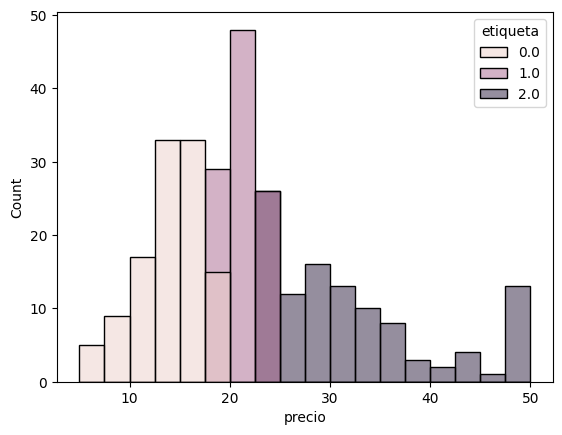

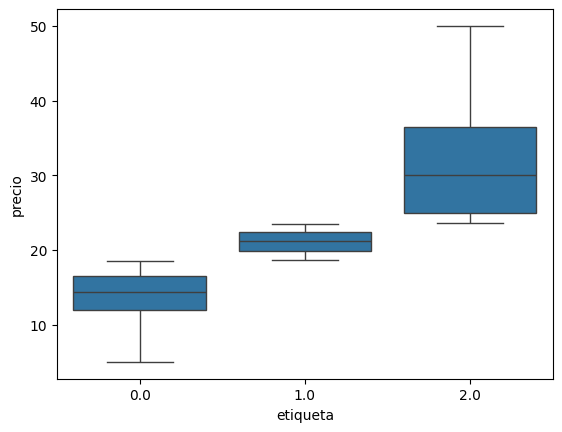

In [ ]:
# Analizamos la distribución de la variable respuesta diferenciando por clase
data = {"precio": y_train, "etiqueta": y_train_labels[:,0]}
df = pd.DataFrame(data=data)
sns.histplot(data=df, x="precio", hue="etiqueta")
plt.figure()
sns.boxplot(data=df, x="etiqueta", y="precio")

Empleamos los mismos umbrales para definir la variable salida de los conjuntos de datos de validación y test

In [ ]:
# Identificamos los índices de los registros para cada grupo
indices_bajo_val = np.where(y_val < 18.7)[0]
indices_medio_val = np.where((y_val >= 18.7) & (y_val < 23.6))[0]
indices_alto_val = np.where(y_val >= 23.6)[0]
print('Registros precios bajos (validación): ', len(indices_bajo_val))
print('Registros precios medios (validación): ', len(indices_medio_val))
print('Registros precios altos (validación): ', len(indices_alto_val))
indices_bajo_test = np.where(y_test < 18.7)[0]
indices_medio_test = np.where((y_test >= 18.7) & (y_test < 23.6))[0]
indices_alto_test = np.where(y_test >= 23.6)[0]
print('Registros precios bajos (test): ', len(indices_bajo_test))
print('Registros precios medios (test): ', len(indices_medio_test))
print('Registros precios altos (test): ', len(indices_alto_test))

# Creamos variable respuesta
y_val_labels = np.zeros(shape=(y_val.shape[0], 1))
y_val_labels[indices_bajo_val, 0] = 0
y_val_labels[indices_medio_val, 0] = 1
y_val_labels[indices_alto_val, 0] = 2

y_test_labels = np.zeros(shape=(y_test.shape[0], 1))
y_test_labels[indices_bajo_test, 0] = 0
y_test_labels[indices_medio_test, 0] = 1
y_test_labels[indices_alto_test, 0] = 2

Registros precios bajos (validación):  26
Registros precios medios (validación):  31
Registros precios altos (validación):  24
Registros precios bajos (test):  26
Registros precios medios (test):  36
Registros precios altos (test):  40


La variable respuesta tiene valores 0, 1, 2 para las clases BAJO, MEDIO, ALTO, respectivamente. Previo a emplear esta variable en la red
neuronal vamos a convertirla a codificación OneHot, donde

In [ ]:
onehot_enc = OneHotEncoder()
y_train_onehot = onehot_enc.fit_transform(y_train_labels).toarray()
y_val_onehot = onehot_enc.fit_transform(y_val_labels).toarray()
y_test_onehot = onehot_enc.fit_transform(y_test_labels).toarray()
print('Valor antes de la codificación: ', y_train_labels[0])
print('Valor después de la codificación: ', y_train_onehot[0])

Valor antes de la codificación:  [0.]
Valor después de la codificación:  [1. 0. 0.]


## Paso 2: Construcción del modelo
En este caso el modelo que debemos construir debe diseñarse para la resolución de un problema de clasificación. En cuanto a la
arquitectura, lo que marca la diferencia entre ambos problemas (regresión y clasificación) es la función de activación de la capa de salida,
donde, en lugar de emplear una función de activación lineal, emplearemos una función de activación Softmax al tratarse de un
problema multiclase.
Otra diferencicia la marca la función de coste a emplear, mientras que para resolver problemas de regresión se suele emplear el error
cuadrárico medio, para resolver problemas de clasificación se emplea la entropía cruzada.
Finalmente, las métricas a emplear serán las propias de un problema de clasificación. Concretamente, emplearemos la precisión.
Así, implementaremos la misma arquitectura con estas diferencias.

In [ ]:
# Creamos un método que define la arquitectura del modelo
def create_model_classification(n_features):
  model = keras.Sequential()
  model.add(Dense(20, activation='relu', input_shape=(n_features,)))
  model.add(Dense(3, activation='softmax')) # El tamaño de la salida ha cambiado a 3 clases
  return model

In [ ]:
# Definimos la arquitectura del modelo
model_classification = create_model_classification(X_train.shape[1])
# Compilamos
model_classification.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_classification.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 343 (1.34 KB)

 Trainable params: 343 (1.34 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamos
history_class = model_classification.fit(X_train_norm, y_train_onehot, epochs=100, batch_size=64, validation_data=(X_val_norm, y_val_onehot))

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 0.3302 - loss: 1.2595 - val_accuracy: 0.3827 - val_loss: 1.1542
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3032 - loss: 1.2135 - val_accuracy: 0.3827 - val_loss: 1.1176
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3026 - loss: 1.1758 - val_accuracy: 0.3827 - val_loss: 1.0917
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3464 - loss: 1.1136 - val_accuracy: 0.4198 - val_loss: 1.0721
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3818 - loss: 1.0916 - val_accuracy: 0.4198 - val_loss: 1.0559
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4130 - loss: 1.0689 - val_accuracy: 0.4691 - val_loss: 1.0432
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4842 - loss: 1.0538 - val_accuracy: 0.4938 - val_loss: 1.0307
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4964 - loss: 1.0368 - val_accuracy: 0.5185 - val_loss

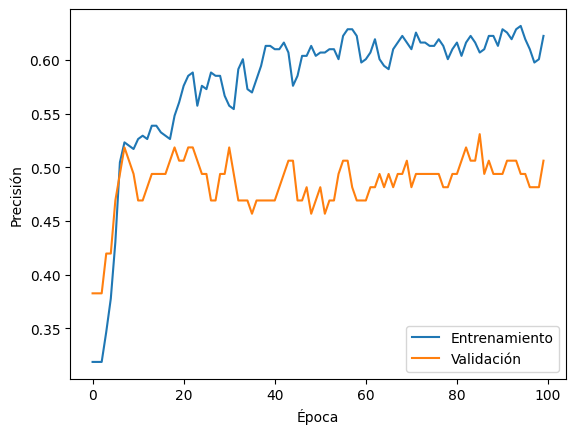

In [ ]:
def plot_history_classification():
  plt.plot(history_class.history['accuracy'], label="Entrenamiento")
  plt.plot(history_class.history['val_accuracy'], label="Validación")
  plt.ylabel('Precisión')
  plt.xlabel('Época')
  plt.legend(loc="lower right")

plot_history_classification()

## Paso 4: Evaluación del modelo

In [ ]:
# Finalmente, evaluamos como se comporta el modelo en el conjunto de datos de test
_, acc = model_classification.evaluate(X_test_norm, y_test_onehot, verbose=0)
print('Precisión en test: ', acc)

Precisión en test:  0.5392156839370728


Con el método "evaluate()" podemos generar únicamente las métricas que definimos en su momento al compilar el modelo.
Por lo que vamos a emplear el método predict() para realizar la predicción. A continuaión generaremos las etiquetas correspondientes y
calcularemos las diferentes métricas

In [ ]:
# Realizamos la predicción del conjunto de test
predictions = model_classification.predict(X_test_norm)
print('Predicción primer registro: ', predictions[0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicción primer registro:  [0.9389649  0.04229526 0.01873993]


In [ ]:
# De la predicción obtenemos la probabilidad de cada clase, para obtener la etiqueta
# correspondiente a cada registro nos quedaremos con la clase que ofrece mayor probabilidad.
predictions_labels = np.argmax(predictions, axis=1)
print('Etiqueta predicción primer registro: ', predictions_labels[0])

Etiqueta predicción primer registro:  0


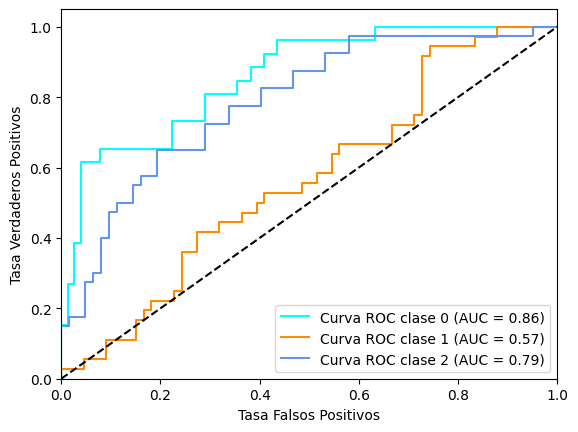

In [ ]:
# Visualización del área bajo la curva ROC
# Dado que es un problema multi-clase se extrae una curva por clase (1 vs el resto)
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

for i in range(n_classes):
  fpr[i], tpr[i], _ = roc_curve(y_test_onehot[:, i], predictions[:, i])
  roc_auc[i] = auc(fpr[i], tpr[i])


colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

for i, color in zip(range(n_classes), colors):
  plt.plot(fpr[i], tpr[i], color=color,
           label='Curva ROC clase {0} (AUC = {1:0.2f})'
           ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa Falsos Positivos')
plt.ylabel('Tasa Verdaderos Positivos')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test_labels, predictions_labels)
print(cm)

[[18  4  4]
 [12  6 18]
 [ 5  4 31]]


Text(50.722222222222214, 0.5, 'Clase real')

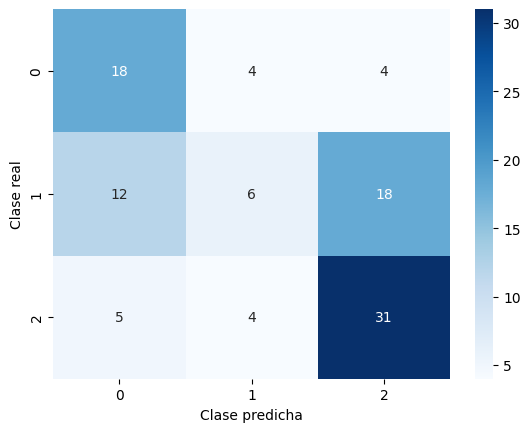

In [ ]:
# Visualizamos la matriz de confusión
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')

Text(50.722222222222214, 0.5, 'Clase real')

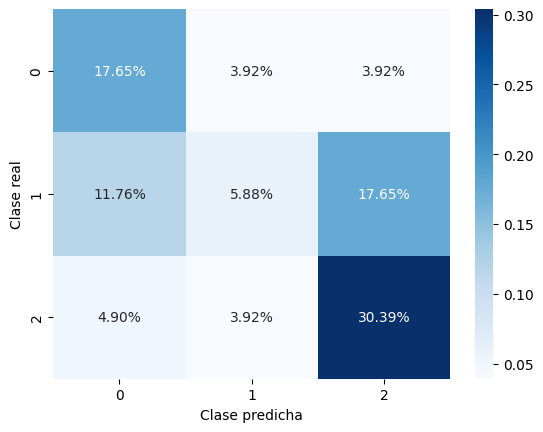

In [ ]:
# Podemos generarlo con los porcentajes de cada clase
sns.heatmap(cm/np.sum(cm), annot=True,
fmt='.2%', cmap='Blues')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')

NOTA: LOS SIGUIENTES NÚMEROS PUEDEN VARIAR ENTRE EJECUCIONES
Observando la matriz de confusión podemos ver que la clase en la que menor error se produce en la predicción es en la clase 0, de los 26
registros que hay de esta clase en el conjunto de datos de test, únicamente 5 están erróneamente clasificadores como clase 1. Por contra,
la mayor cantidad de errores se produce en la clase 1, donde 14 de los 36 registros se han clasificado erróneamente, 7 se han clasificado
como pertenecientes a la clase 0 y otros 7 como clase 2.

Para evaluar las métricas en problemas multi-clase, las métricas se pueden extraer a dos/tres niveles diferentes.


*   Micro: Se considera el valor global de VP, FP, VN y FN sin considerar cada clase individualmente. En nuestro ejemplo:

VP: 21 + 22 + 29 = 72

FP: (7+1) + (5+10) + (0+7) = 30

FN: (5+0) + (7+7) + (1+10) = 30

En el nivel micro se obtiene que Exactitud = Recall = F1 Score = Precisión


*   Macro: Se calculan las métricas para cada clase individualmente y se calcula la media aritmética de cada métrica.
*   Ponderado: Es similar a la anterior, pero en este caso, se pondera la media. El peso que se le asigna a cada clase se corresponde el número total de muestras de esa clase.


Todas estas métricas se pueden calcular haciendo uso de la libería scikit-learn (sklearn):

In [ ]:
print('Precisión: {:.2f}\n'.format(accuracy_score(y_test_labels, predictions_labels)))
print('Micro Exactitud: {:.2f}'.format(precision_score(y_test_labels, predictions_labels, average='micro')))
print('Micro Recall: {:.2f}'.format(recall_score(y_test_labels, predictions_labels, average='micro')))
print('Micro F1-score: {:.2f}\n'.format(f1_score(y_test_labels, predictions_labels, average='micro')))
print('Macro Exactitud: {:.2f}'.format(precision_score(y_test_labels, predictions_labels, average='macro')))
print('Macro Recall: {:.2f}'.format(recall_score(y_test_labels, predictions_labels, average='macro')))
print('Macro F1-score: {:.2f}\n'.format(f1_score(y_test_labels, predictions_labels, average='macro')))
print('Weighted Exactitud: {:.2f}'.format(precision_score(y_test_labels, predictions_labels, average='weighted')))
print('Weighted Recall: {:.2f}'.format(recall_score(y_test_labels, predictions_labels, average='weighted')))
print('Weighted F1-score: {:.2f}'.format(f1_score(y_test_labels, predictions_labels, average='weighted')))
print('\nInforme clasificación:\n')
print(classification_report(y_test_labels, predictions_labels, target_names=['BAJO', 'MEDIO', 'ALTO']))

Precisión: 0.54

Micro Exactitud: 0.54
Micro Recall: 0.54
Micro F1-score: 0.54

Macro Exactitud: 0.51
Macro Recall: 0.54
Macro F1-score: 0.50

Weighted Exactitud: 0.51
Weighted Recall: 0.54
Weighted F1-score: 0.50

Informe clasificación:

              precision    recall  f1-score   support

        BAJO       0.51      0.69      0.59        26
       MEDIO       0.43      0.17      0.24        36
        ALTO       0.58      0.78      0.67        40

    accuracy                           0.54       102
   macro avg       0.51      0.54      0.50       102
weighted avg       0.51      0.54      0.50       102



## Paso 5: Guardado del modelo e inferencia

Para poder emplear el modelo en producción es necesario guardar el mismo para no tener que ajustarlo cada que queramos emplearlo en
producción.

In [ ]:
# Guardamos del modelo entrenado
model_classification.save('./my_model.h5')

In [ ]:
# Cargamos el modelo entrenado
new_model = keras.models.load_model('./my_model.h5')
X_pred = X_test[0,:]
# Normalizamos el registro con la media y std empleada en el entrenamiento
media = np.load('./mean.npy')
std = np.load('./std.npy')
X_pred = (X_pred - media) / std
# Ajustamos la entrada para realizar la predicción a (n_casos, n_características)
# 1 porque queremos realizar la predicción de un único caso.

X_pred = np.reshape(X_pred,(1, len(X_pred)))
# Realizamos predicción
pred = new_model.predict(X_pred)
print('Predicción del modelo: ', pred)
# Extraemos la etiqueta correspondiente
pred_label = np.argmax(pred)
print('Clase predicción: ', pred_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
Predicción del modelo:  [[0.9389649  0.04229525 0.01873992]]
Clase predicción:  0


## Complejidad arquitectura

En esta sección vamos a tratar de generar una arquitectura más compleja para ver si esta nos ofrece mejores resultados.
Para aumentar la complejidad de una arquitectura podemos tanto crear redes más profundas, es decir, con más capas ocultas, o incluir
más neuronas en estas capas ocultas.

### Prueba 1: Incrementamos el número de neuronas en la capa oculta

In [ ]:
def create_model_classification_nodes(n_features, n_hidden_nodes):
  model = keras.Sequential()
  model.add(Dense(n_hidden_nodes, activation='relu', input_shape=(n_features,)))
  model.add(Dense(3, activation='softmax')) # El tamaño de la salida ha cambiado a 3 clases
  return model

In [ ]:
# Probamos con 50, 100, 200 y 500 neuronas
model_50 = create_model_classification_nodes(X_train.shape[1], 50)
model_50.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_100 = create_model_classification_nodes(X_train.shape[1], 100)
model_100.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_200 = create_model_classification_nodes(X_train.shape[1], 200)
model_200.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_500 = create_model_classification_nodes(X_train.shape[1], 500)
model_500.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Entrenamos los modelos (verbose=0 para que no salgan los logs del entrenamiento)
history_50 = model_50.fit(X_train_norm, y_train_onehot, epochs=100, batch_size=64, validation_data=(X_val_norm, y_val_onehot), verbose=0)

history_100 = model_100.fit(X_train_norm, y_train_onehot, epochs=100, batch_size=64, validation_data=(X_val_norm, y_val_onehot), verbose=0)

history_200 = model_200.fit(X_train_norm, y_train_onehot, epochs=100, batch_size=64, validation_data=(X_val_norm, y_val_onehot), verbose=0)

history_500 = model_500.fit(X_train_norm, y_train_onehot, epochs=100, batch_size=64, validation_data=(X_val_norm, y_val_onehot), verbose=0)

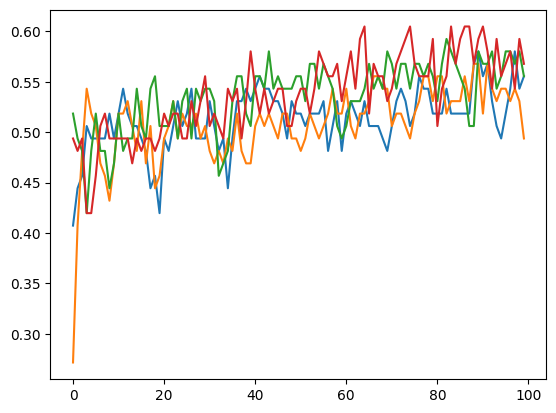

In [ ]:
# Comparamos métricas validación
#plt.plot(history_class.history['val_accuracy'], label="20 neuronas")
plt.plot(history_50.history['val_accuracy'], label="50 neuronas")
plt.plot(history_100.history['val_accuracy'], label="100 neuronas")
plt.plot(history_200.history['val_accuracy'], label="200 neuronas")
plt.plot(history_500.history['val_accuracy'], label="500 neuronas")